<a href="https://colab.research.google.com/github/Adithyaanil121/report/blob/main/ml_report_26_09_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score



In [2]:
# 1. Load the dataset

data = fetch_california_housing()

X = data.data[:, 0] # MedInc - Median Income
y = data.target # House price

# Use only a small number of samples for easy visualization
X = X[:1000]
y = y[:1000]



In [3]:
# Convert X into column format
X = X.reshape(-1, 1)# 2. Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# 3. Gradient Descent

# Start with initial values
m = 0 # slope
b = 0 # intercept

learning_rate = 0.01
epochs = 1000

n = len(X_train)

for i in range(epochs):

    # Predicted values
    y_pred = m * X_train[:, 0] + b

    # Calculate errors
    error = y_pred - y_train

    # Calculate gradients
    dm = (2 / n) * np.sum(error * X_train[:, 0])
    db = (2 / n) * np.sum(error)

    # Update m and b
    m = m - learning_rate * dm
    b = b - learning_rate * db

# Predictions using Gradient Descent
y_pred_gd = m * X_test[:, 0] + b

# Calculate performance
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent")
print("Slope (m):", m)
print("Intercept (b):", b)
print("MSE:", mse_gd)
print("R-squared:", r2_gd)

Gradient Descent
Slope (m): 0.3720498038116302
Intercept (b): 0.6911381842083504
MSE: 0.2391927252794377
R-squared: 0.6710267685725706


In [5]:
# 4. Normal Equation

# Add a column of 1s for the intercept
X_train_new = np.c_[np.ones(len(X_train)), X_train]

# Normal Equation:
# theta = (X^T X)^-1 X^T y

theta = np.linalg.inv(
    X_train_new.T @ X_train_new
) @ X_train_new.T @ y_train

b_ne = theta[0]
m_ne = theta[1]

# Predictions
y_pred_ne = m_ne * X_test[:, 0] + b_ne

# Calculate performance
mse_ne = mean_squared_error(y_test, y_pred_ne)
r2_ne = r2_score(y_test, y_pred_ne)

print("\nNormal Equation")
print("Slope (m):", m_ne)
print("Intercept (b):", b_ne)
print("MSE:", mse_ne)
print("R-squared:", r2_ne)


Normal Equation
Slope (m): 0.36821218247789456
Intercept (b): 0.7090929614048702
MSE: 0.24114777958489753
R-squared: 0.6683378885837169


In [6]:
# 5. Compare the results

print("\nComparison")
print("-------------------------------")
print("Method MSE R2")
print(
    "Gradient Descent ",
    round(mse_gd, 4),
    round(r2_gd, 4)
)
print(
    "Normal Equation ",
    round(mse_ne, 4),
    round(r2_ne, 4)
)


Comparison
-------------------------------
Method MSE R2
Gradient Descent  0.2392 0.671
Normal Equation  0.2411 0.6683


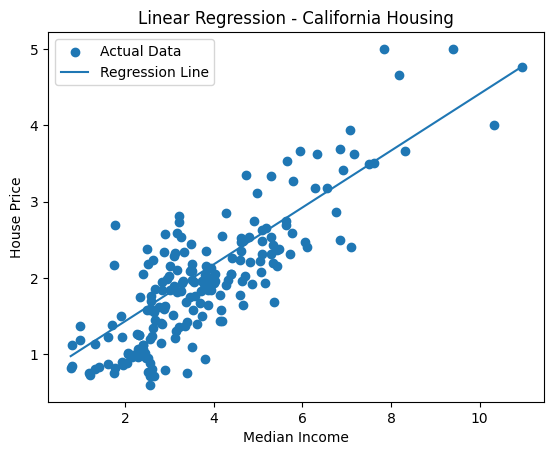

In [7]:
# 6. Visualization

plt.scatter(X_test, y_test, label="Actual Data")

# Sort X values for a smooth line
order = X_test[:, 0].argsort()

X_sorted = X_test[order]

# Gradient Descent line
y_line = m * X_sorted[:, 0] + b

plt.plot(
    X_sorted,
    y_line,
    label="Regression Line"
)

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Linear Regression - California Housing")

plt.legend()
plt.show()